In [1]:
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
#from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline
#import xesmf as xe

from utils import QACC_utils
from utils.config import model, min_lat, max_lat, min_year_late_cent, max_year_late_cent

In [2]:
# get the spatial mean variables (monthly) 
# - but note we also need some variables with spatial resolution for kernel cals

ds_sm_ssp245 = xr.open_dataset('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
            s='ssp245', l=str(min_lat), m=model))
ds_sm_arise = xr.open_dataset('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
            s='ARISE', l=str(min_lat), m=model))

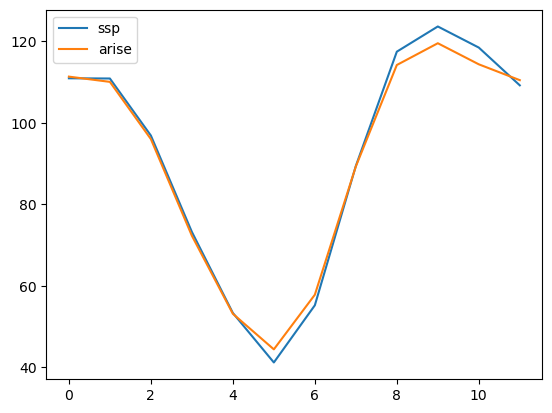

In [3]:
plt.plot(ds_sm_ssp245.AHT.values, label='ssp')
plt.plot(ds_sm_arise.AHT.values, label='arise')
plt.legend()

In [4]:
#plt.plot(ds_delta_sm.AHT.values)

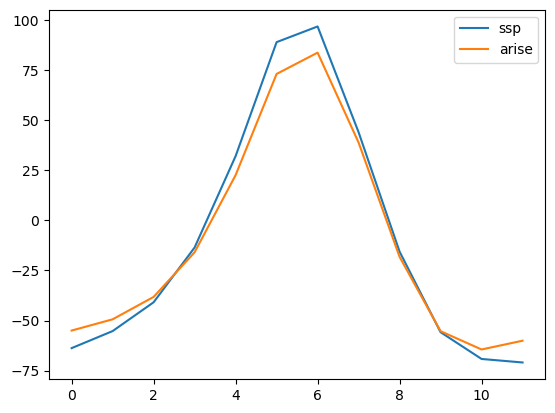

In [5]:
plt.plot(ds_sm_ssp245.OHU.values, label='ssp')
plt.plot(ds_sm_arise.OHU.values, label='arise')
plt.legend()

In [6]:
# read in feedbacks (W/m2 - so R units)
Rs = xr.open_dataset('intermediate_outputs/feedbacks.nc')

Planck_global_mean_lambda = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K
Planck_global_mean_cs_lambda = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K

Rs['Planck_dash'] = (Rs['Planck']/Rs['delta_TS'] - Planck_global_mean_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units
Rs['Planck_dash_cs'] = (Rs['Planck_cs']/Rs['delta_TS'] - Planck_global_mean_cs_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units


Rs_arctic_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(min_lat, max_lat)), 'lon', 'lat')


In [7]:
Rs_arctic_mean

<xarray.Dataset> Size: 2kB
Dimensions:         (time: 12)
Coordinates:
  * time            (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height          float64 8B ...
    units           <U5 20B ...
Data variables: (12/15)
    LR              (time) float64 96B -3.539 -2.453 -1.517 ... -4.737 -4.529
    Planck          (time) float64 96B 10.8 8.283 6.347 ... 9.294 14.06 14.11
    WV              (time) float64 96B -0.2853 -0.3899 ... -0.7524 -0.3404
    Alb             (time) float64 96B -0.01005 -0.1914 ... -0.03103 -9.017e-05
    LR_cs           (time) float64 96B -2.22 -1.453 -0.7318 ... -2.762 -2.847
    Planck_cs       (time) float64 96B 10.97 8.397 6.366 ... 9.324 14.28 14.42
    ...              ...
    T_strat_cs      (time) float64 96B 0.704 0.8972 0.7053 ... -0.1024 0.1915
    q_strat         (time) float64 96B -0.02312 -0.04868 ... -0.05724 -0.03911
    q_strat_cs      (time) float64 96B -0.02474 -0.05062 ... -0.06065 -0.04083
    delta_TS        (time) float64 96B -5.191 -4.106 -3.367 ... -6.735 -6.814
    Planck_dash     (time) float64 96B 0.7403 0.5152 0.1417 ... 1.246 0.8992
    Planck_dash_cs  (time) float64 96B 1.242 0.9364 0.4368 ... 1.324 1.932 1.669

In [8]:
ds_delta_sm = (ds_sm_arise - ds_sm_ssp245).rename({'month':'time'})
print(ds_delta_sm.tas.mean('time').item())

-3.7508027092677856


In [9]:
ds_delta_sm

<xarray.Dataset> Size: 9kB
Dimensions:                 (time: 12, plev: 19, bnds: 2)
Coordinates:
    height                  float64 8B 1.5
  * time                    (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev                    (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
Dimensions without coordinates: bnds
Data variables: (12/34)
    lat_bounds              (time, bnds) float64 192B 0.0 0.0 0.0 ... 0.0 0.0
    lon_bounds              (time, bnds) float64 192B 0.0 0.0 0.0 ... 0.0 0.0
    tas                     (time) float64 96B -5.191 -4.106 ... -6.735 -6.814
    number_ens_mems_meaned  (time) float64 96B -10.0 -10.0 -10.0 ... -10.0 -10.0
    rsds                    (time) float64 96B 0.01452 -0.1222 ... 0.001141
    rsus                    (time) float64 96B 0.01948 0.1073 ... 0.0007428
    ...                      ...
    Qmoist                  (time) float64 96B -0.2797 -0.4677 ... -0.5693
    Qdry                    (time) float64 96B 0.6859 -0.3581 ... -1.755 1.839
    IRF_aer                 (time) float64 96B -0.06968 -0.7107 ... -0.002757
    IRF_aer_cs              (time) float64 96B -0.1059 -1.158 ... -0.003584
    albedo                  (time) float64 96B 0.03174 0.01973 ... 0.027 0.02584
    CRE                     (time) float64 96B -2.618 -1.211 ... -4.522 -4.4

In [34]:
all_feedbacks = ['Planck', 'Alb', 'LR', 'WV', 'T_strat', 'q_strat']
feedback_masking = sum([(Rs_arctic_mean[str(feedback+'_cs')] - Rs_arctic_mean[feedback]) for feedback in all_feedbacks])
IRF_masking = -1*(ds_delta_sm['IRF_aer_cs'] - ds_delta_sm['IRF_aer'])

cloud_R = ds_delta_sm['CRE'] + IRF_masking + feedback_masking

#cloud_R = ds_delta_sm['CRE']+ feedback_masking

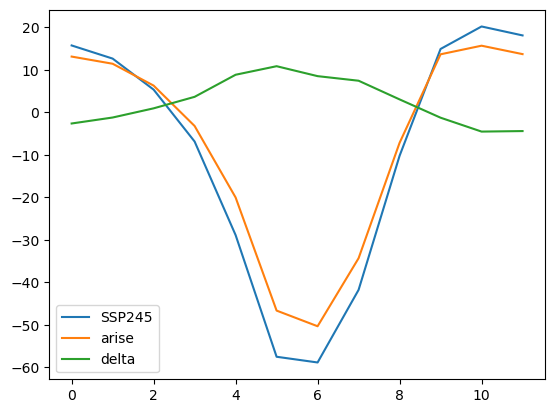

In [35]:
plt.plot(ds_sm_ssp245['CRE'], label='SSP245')
plt.plot(ds_sm_arise['CRE'], label='arise')
plt.plot(ds_delta_sm['CRE'], label='delta')

plt.legend()

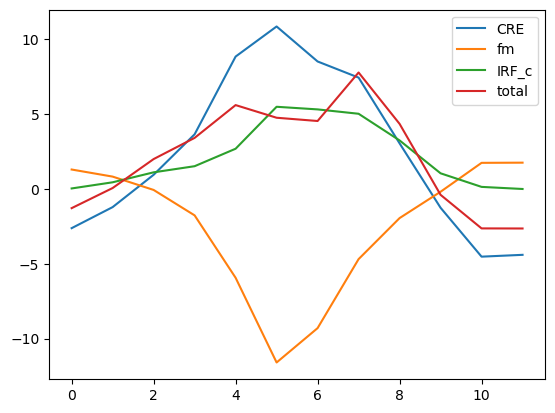

In [36]:
plt.plot(ds_delta_sm['CRE'], label='CRE')
plt.plot(feedback_masking, label='fm')
plt.plot(IRF_masking, label='IRF_c')
plt.plot(cloud_R, label='total')
plt.legend()

In [37]:
delta_T_contribs = {
    'F':-(ds_delta_sm['IRF_aer'] + Rs_arctic_mean['T_strat'] + Rs_arctic_mean['q_strat'])/Planck_global_mean_lambda, # include strat adjustement, to get F from IRF
    'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
    'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda,
    'Planck':-Rs_arctic_mean['Planck_dash']/Planck_global_mean_lambda,
    'Alb':-Rs_arctic_mean['Alb']/Planck_global_mean_lambda,
    'LR':-Rs_arctic_mean['LR']/Planck_global_mean_lambda,
    'WV':-Rs_arctic_mean['WV']/Planck_global_mean_lambda,
    'Cloud':-cloud_R/Planck_global_mean_lambda}


In [38]:
#delta_T_contribs

In [47]:
df = pd.DataFrame(delta_T_contribs)
df['Month'] = Rs_arctic_mean.time.values
total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
residuals = ds_delta_sm.tas.values - total_T_contribs
df['Residual'] = residuals

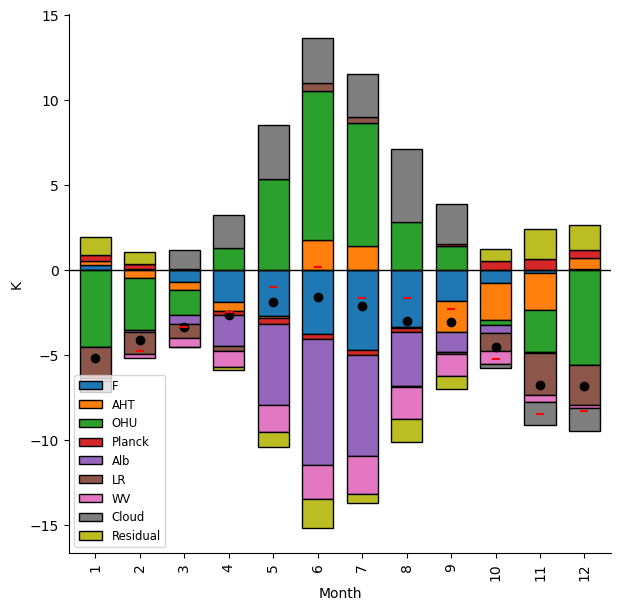

In [50]:
fig, ax = plt.subplots(1, 1, figsize = (7, 7))#, sharey=True)
    
i=0

T = ds_delta_sm.tas.values
df.plot(kind = "bar",
        x='Month',
        stacked = True,
        ax = ax,
        width = 0.7,
        edgecolor = "black")

ax.scatter(df['Month']-1, T, c='black')
ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')

#ax.plot(range(len(df)), df['tas'], c='red', ls='--')
#ax.set_title(title)
ax.set_ylabel('K')
ax.axhline(y=0, c='black', lw=1)
#ax.axhline(y=mean, c='black', lw=1, ls='--')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(fontsize='small', loc='lower left')

plt.savefig('figures/Cooling_contribs_ARISE.jpg', dpi=400)